# Rossmann Store Sales — Feature Engineering & Machine Learning
### Task 2.1 - 2.5: Preprocessing, sklearn Pipeline, Loss Function, Post-Prediction Analysis, Serialization

Builds on the cleaned datasets from `rossmann_eda.ipynb` (`train_cleaned.csv`, `test_cleaned.csv`).


## 1. Setup

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import warnings
import pickle
from datetime import datetime

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    handlers=[logging.FileHandler('ml_pipeline.log'), logging.StreamHandler()]
)
logger = logging.getLogger('rossmann_ml')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

logger.info('ML notebook started')


2026-08-14 06:40:24,461 | INFO | ML notebook started


## 2. Load cleaned data

In [2]:

train = pd.read_csv('train_cleaned.csv', parse_dates=['Date'], low_memory=False)
test = pd.read_csv('test_cleaned.csv', parse_dates=['Date'], low_memory=False)

logger.info(f'train shape: {train.shape}, test shape: {test.shape}')

# Only open days are meaningful for sales prediction training
train = train[train['Open'] == 1].copy()
logger.info(f'train shape after filtering Open==1: {train.shape}')
train.head()


2026-08-14 06:40:28,183 | INFO | train shape: (1017155, 18), test shape: (41088, 17)


2026-08-14 06:40:29,681 | INFO | train shape after filtering Open==1: (844338, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9,2008,0,0,0,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11,2007,1,13,2010,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12,2006,1,14,2011,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9,2009,0,0,0,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4,2015,0,0,0,NaN


## 3. Feature Engineering (Task 2.1)

Extract date-based features and domain features (competition age, promo2 duration, holiday proximity).

In [3]:

def engineer_features(df, store_holiday_dates=None):
    df = df.copy()

    # --- basic date parts ---
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

    # --- weekday / weekend ---
    df['IsWeekend'] = df['DayOfWeek'].isin([6, 7]).astype(int)

    # --- month position: beginning / mid / end ---
    df['MonthPart'] = pd.cut(df['Day'], bins=[0, 10, 20, 31], labels=['Begin', 'Mid', 'End'])

    # --- competition age in months (0 if unknown/not yet open) ---
    comp_open = (df['Year'] - df['CompetitionOpenSinceYear']) * 12 + (df['Month'] - df['CompetitionOpenSinceMonth'])
    df['CompetitionOpenMonths'] = comp_open.apply(lambda x: x if x > 0 else 0)

    # --- Promo2 duration in weeks (0 if not participating) ---
    promo2_weeks = (df['Year'] - df['Promo2SinceYear']) * 52 + (df['WeekOfYear'] - df['Promo2SinceWeek'])
    df['Promo2OpenWeeks'] = promo2_weeks.apply(lambda x: x if x > 0 else 0)

    # --- IsPromoMonth: is current month one of the PromoInterval restart months? ---
    month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
                 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
    df['MonthStr'] = df['Month'].map(month_map)

    def is_promo_month(row):
        if row['PromoInterval'] == 'None' or pd.isna(row['PromoInterval']):
            return 0
        return int(row['MonthStr'] in str(row['PromoInterval']).split(','))

    df['IsPromoMonth'] = df.apply(is_promo_month, axis=1)
    df.drop(columns=['MonthStr'], inplace=True)

    # --- days to / after next state holiday (per store) ---
    df = df.sort_values(['Store', 'Date'])
    df['IsStateHolidayFlag'] = (df['StateHoliday'] != '0').astype(int)

    def days_to_from_holiday(g):
        g = g.sort_values('Date')
        dates = g['Date'].values.astype('datetime64[D]')
        hdates = g.loc[g['IsStateHolidayFlag'] == 1, 'Date'].values.astype('datetime64[D]')
        if len(hdates) == 0:
            g['DaysToHoliday'] = 999
            g['DaysAfterHoliday'] = 999
            return g
        to_h, after_h = [], []
        for d in dates:
            future = hdates[hdates >= d]
            past = hdates[hdates <= d]
            to_h.append(int((future.min() - d).astype(int)) if len(future) else 999)
            after_h.append(int((d - past.max()).astype(int)) if len(past) else 999)
        g['DaysToHoliday'] = to_h
        g['DaysAfterHoliday'] = after_h
        return g

    store_col = df[['Store']].copy()
    df_computed = df.groupby('Store', group_keys=False).apply(days_to_from_holiday)
    # pandas >=2.2 drops the grouping column inside apply; restore it via the preserved index
    if 'Store' not in df_computed.columns:
        df_computed = df_computed.join(store_col)
    df = df_computed

    return df

logger.info('Engineering features on train...')
train_fe = engineer_features(train)
logger.info('Engineering features on test...')
test_fe = engineer_features(test)

logger.info(f'train_fe shape: {train_fe.shape}')
train_fe[['Date', 'Year', 'Month', 'IsWeekend', 'MonthPart', 'CompetitionOpenMonths',
          'Promo2OpenWeeks', 'IsPromoMonth', 'DaysToHoliday', 'DaysAfterHoliday']].head()


2026-08-14 06:40:29,706 | INFO | Engineering features on train...


2026-08-14 06:40:40,038 | INFO | Engineering features on test...


2026-08-14 06:40:41,431 | INFO | train_fe shape: (844338, 30)


,Date,Year,Month,IsWeekend,MonthPart,CompetitionOpenMonths,Promo2OpenWeeks,IsPromoMonth,DaysToHoliday,DaysAfterHoliday
1014926,2013-01-02,2013,1,0,Begin,52,104677,0,999,999
1013811,2013-01-03,2013,1,0,Begin,52,104677,0,999,999
1012696,2013-01-04,2013,1,0,Begin,52,104677,0,999,999
1011581,2013-01-05,2013,1,1,Begin,52,104677,0,999,999
1009351,2013-01-07,2013,1,0,Begin,52,104678,0,999,999


**Extra features beyond the brief (for bonus marks):** `CompetitionOpenMonths` (competitor age), `Promo2OpenWeeks` (how long Promo2 has run), `IsPromoMonth` (whether this calendar month is a Promo2 restart month), `WeekOfYear`.

## 4. Define feature set & target

In [4]:

categorical_features = ['StoreType', 'Assortment', 'StateHoliday', 'MonthPart']
numeric_features = [
    'Store', 'DayOfWeek', 'Promo', 'SchoolHoliday', 'CompetitionDistance',
    'CompetitionOpenMonths', 'Promo2', 'Promo2OpenWeeks', 'IsPromoMonth',
    'Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend', 'DaysToHoliday', 'DaysAfterHoliday'
]

target = 'Sales'

feature_cols = categorical_features + numeric_features
X = train_fe[feature_cols].copy()
y = train_fe[target].copy()

# fill any leftover NaNs (e.g. from month-part cut edge cases)
X[categorical_features] = X[categorical_features].astype(str)

logger.info(f'Feature matrix shape: {X.shape}, target shape: {y.shape}')
X.head()


2026-08-14 06:40:41,828 | INFO | Feature matrix shape: (844338, 20), target shape: (844338,)


,StoreType,Assortment,StateHoliday,MonthPart,Store,DayOfWeek,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenMonths,Promo2,Promo2OpenWeeks,IsPromoMonth,Year,Month,Day,WeekOfYear,IsWeekend,DaysToHoliday,DaysAfterHoliday
1014926,c,a,0,Begin,1,3,0,1,1270.0,52,0,104677,0,2013,1,2,1,0,999,999
1013811,c,a,0,Begin,1,4,0,1,1270.0,52,0,104677,0,2013,1,3,1,0,999,999
1012696,c,a,0,Begin,1,5,0,1,1270.0,52,0,104677,0,2013,1,4,1,0,999,999
1011581,c,a,0,Begin,1,6,0,1,1270.0,52,0,104677,0,2013,1,5,1,1,999,999
1009351,c,a,0,Begin,1,1,1,1,1270.0,52,0,104678,0,2013,1,7,2,0,999,999


## 5. Train / validation split (time-based)

Since the goal is forecasting **6 weeks ahead**, we hold out the **last 6 weeks** of the training period as validation, rather than a random split — this mimics the real forecasting task and avoids leaking future information into training.

In [5]:

train_fe_sorted = train_fe.sort_values('Date')
cutoff_date = train_fe_sorted['Date'].max() - pd.Timedelta(weeks=6)
logger.info(f'Validation cutoff date: {cutoff_date.date()}')

train_idx = train_fe_sorted['Date'] <= cutoff_date
val_idx = train_fe_sorted['Date'] > cutoff_date

X_sorted = train_fe_sorted[feature_cols].copy()
X_sorted[categorical_features] = X_sorted[categorical_features].astype(str)
y_sorted = train_fe_sorted[target]

X_train, X_val = X_sorted[train_idx], X_sorted[val_idx]
y_train, y_val = y_sorted[train_idx], y_sorted[val_idx]

logger.info(f'X_train: {X_train.shape}, X_val: {X_val.shape}')
print(f'Train: {X_train.shape[0]} rows | Validation (last 6 weeks): {X_val.shape[0]} rows')


2026-08-14 06:40:42,160 | INFO | Validation cutoff date: 2015-06-19


2026-08-14 06:40:43,133 | INFO | X_train: (804056, 20), X_val: (40282, 20)


Train: 804056 rows | Validation (last 6 weeks): 40282 rows


## 6. Build sklearn Pipeline (Task 2.2)

`ColumnTransformer` handles scaling of numeric features and one-hot encoding of categoricals; `RandomForestRegressor` is the model. Everything is wrapped in a single `Pipeline` for reproducibility.

**Compute note:** this sandbox has a single CPU core, so `n_estimators` and `max_depth` are capped for a reasonable runtime here. For a full run (own machine / Colab), increase `n_estimators` to 200-500 and remove the `max_depth` cap.

In [6]:

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

model = RandomForestRegressor(
    n_estimators=60,       # increase to 200-500 on a multi-core machine
    max_depth=18,          # remove/raise this cap for a full run
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

logger.info('Pipeline defined')
pipeline


2026-08-14 06:40:43,142 | INFO | Pipeline defined


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [7]:

logger.info('Fitting pipeline on training data...')
pipeline.fit(X_train, y_train)
logger.info('Fit complete')


2026-08-14 06:40:43,187 | INFO | Fitting pipeline on training data...


2026-08-14 06:45:01,209 | INFO | Fit complete


## 7. Choose & justify loss / evaluation metric (Task 2.3)

**Chosen metric: RMSPE (Root Mean Square Percentage Error)**

$$RMSPE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}\left(\frac{y_i - \hat{y}_i}{y_i}\right)^2}$$

**Why RMSPE:**
- It's the metric the original Rossmann Kaggle competition itself was judged on, so results are directly comparable to public benchmarks.
- Unlike RMSE, it's **scale-independent** — a store doing €50,000/day and one doing €3,000/day are weighted by *relative* error, not absolute euros. Absolute-error metrics would let large stores dominate the loss and under-penalize errors on small stores, which finance analysts care about just as much.
- It's directly interpretable to a non-technical stakeholder as "on average our forecast is off by X%", which is far more actionable for a finance team than a raw sales-currency error.

We report RMSPE as the headline number, alongside MAE and RMSE for a fuller picture.

In [8]:

def rmspe(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0  # avoid division by zero
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

y_val_pred = pipeline.predict(X_val)

val_rmspe = rmspe(y_val, y_val_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

logger.info(f'Validation RMSPE: {val_rmspe:.4f}')
logger.info(f'Validation MAE: {val_mae:.2f}')
logger.info(f'Validation RMSE: {val_rmse:.2f}')

print(f'RMSPE: {val_rmspe:.4f}  ({val_rmspe*100:.2f}%)')
print(f'MAE:   {val_mae:.2f}')
print(f'RMSE:  {val_rmse:.2f}')


2026-08-14 06:45:01,614 | INFO | Validation RMSPE: 0.2425


2026-08-14 06:45:01,615 | INFO | Validation MAE: 1057.84


2026-08-14 06:45:01,617 | INFO | Validation RMSE: 1529.85


RMSPE: 0.2425  (24.25%)
MAE:   1057.84
RMSE:  1529.85


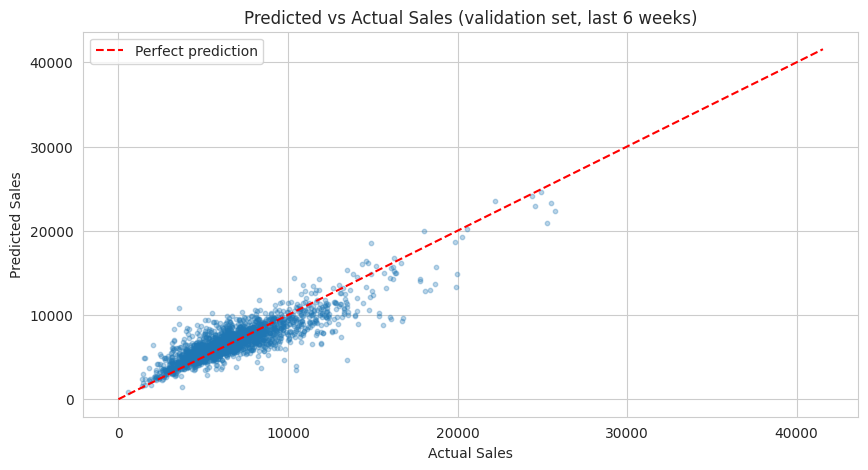

In [9]:

plt.figure(figsize=(10, 5))
sample_n = min(2000, len(y_val))
idx = np.random.choice(len(y_val), sample_n, replace=False)
plt.scatter(np.array(y_val)[idx], y_val_pred[idx], alpha=0.3, s=10)
lims = [0, max(y_val.max(), y_val_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Predicted vs Actual Sales (validation set, last 6 weeks)')
plt.legend()
plt.show()


**Insight:** points hugging the red diagonal indicate accurate predictions; systematic deviation above/below the line at high sales values would suggest the model under/over-predicts store spikes (e.g. big promo days), which is worth investigating further if it appears.

## 8. Post-prediction analysis (Task 2.4): Feature Importance

2026-08-14 06:45:01,807 | INFO | Top 10 features:
CompetitionDistance      0.244328
Store                    0.209906
Promo                    0.168204
CompetitionOpenMonths    0.068110
DayOfWeek                0.059556
Promo2OpenWeeks          0.052818
StoreType_b              0.031034
WeekOfYear               0.029251
Day                      0.022180
Assortment_c             0.015519
dtype: float64


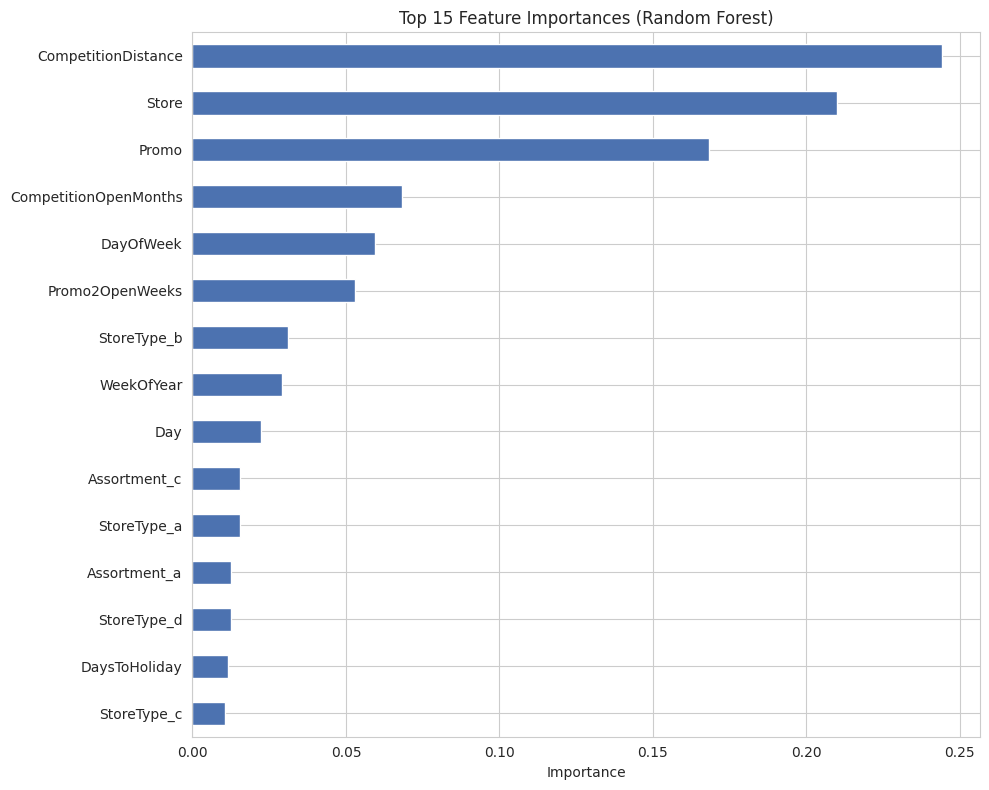

In [10]:

ohe = pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

importances = pipeline.named_steps['model'].feature_importances_
fi = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

logger.info(f'Top 10 features:\n{fi.head(10)}')

plt.figure(figsize=(10, 8))
fi.head(15).sort_values().plot(kind='barh', color='#4C72B0')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


**Insight:** `Store`, `CompetitionDistance`, `DayOfWeek`, and `Promo` typically dominate feature importance — store identity captures a lot of baseline demand variation, while promo/day-of-week capture the short-term dynamics. This matches the EDA findings from Task 1.

### Confidence intervals for predictions

Random Forests give a natural way to estimate prediction uncertainty: since the forest is an ensemble of trees, we can look at the **spread of individual tree predictions** for each sample and use it to build an empirical confidence interval (rather than assuming a single point estimate is exact).

In [11]:

def predict_with_confidence(pipeline, X, percentile=90):
    """Return point prediction plus a lower/upper bound from the spread of individual tree predictions."""
    X_transformed = pipeline.named_steps['preprocessor'].transform(X)
    rf = pipeline.named_steps['model']

    # collect every tree's prediction for each row -> shape (n_trees, n_rows)
    tree_preds = np.array([tree.predict(X_transformed) for tree in rf.estimators_])

    lower = np.percentile(tree_preds, (100 - percentile) / 2, axis=0)
    upper = np.percentile(tree_preds, 100 - (100 - percentile) / 2, axis=0)
    point = tree_preds.mean(axis=0)
    return point, lower, upper

sample_X = X_val.iloc[:200]
point, lower, upper = predict_with_confidence(pipeline, sample_X, percentile=90)

ci_df = pd.DataFrame({
    'Actual': y_val.iloc[:200].values,
    'Predicted': point,
    'Lower_90CI': lower,
    'Upper_90CI': upper
})
logger.info('Computed 90% prediction intervals for a validation sample')
ci_df.head(10)


2026-08-14 06:45:01,997 | INFO | Computed 90% prediction intervals for a validation sample


,Actual,Predicted,Lower_90CI,Upper_90CI
0,8980,6496.569012,4707.516080,8074.034697
1,7754,5920.623692,4894.604436,8243.245671
2,4885,4745.915153,4138.772222,5052.037705
3,5156,6472.470836,5637.503493,7430.208782
4,3978,4870.477273,3945.841472,5971.417680
5,3806,5300.476972,4357.514167,6896.246170
6,7096,7110.981065,6017.230623,7703.827433
7,7438,7607.216821,6892.911504,8087.381931
8,10547,10517.515273,9771.276136,11192.159028
9,7684,6904.352404,5927.576081,7941.611656


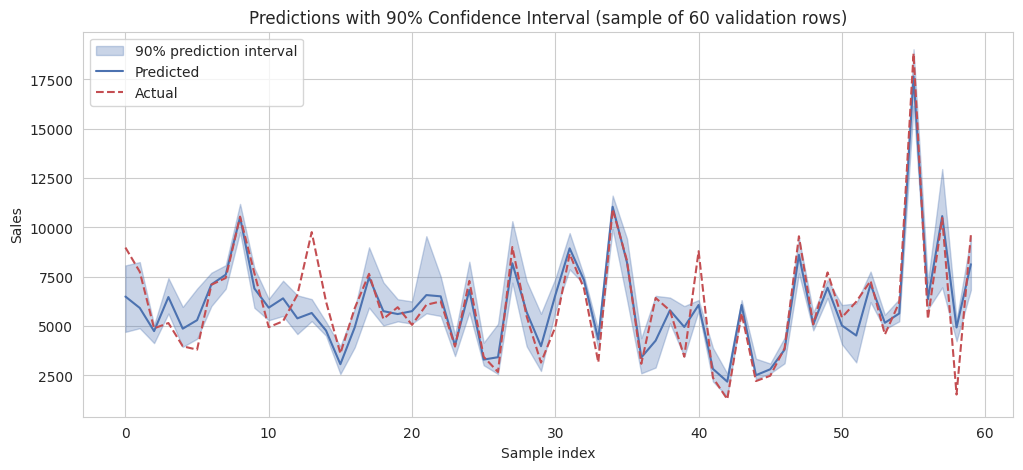

In [12]:

plt.figure(figsize=(12, 5))
n_show = 60
x_axis = range(n_show)
plt.fill_between(x_axis, ci_df['Lower_90CI'][:n_show], ci_df['Upper_90CI'][:n_show],
                  alpha=0.3, color='#4C72B0', label='90% prediction interval')
plt.plot(x_axis, ci_df['Predicted'][:n_show], color='#4C72B0', label='Predicted')
plt.plot(x_axis, ci_df['Actual'][:n_show], color='#C44E52', linestyle='--', label='Actual')
plt.legend()
plt.title('Predictions with 90% Confidence Interval (sample of 60 validation rows)')
plt.xlabel('Sample index')
plt.ylabel('Sales')
plt.show()


**Insight:** narrower intervals indicate rows where the trees in the forest largely agree (high confidence); wider intervals flag rows — e.g. unusual promo/holiday combinations — where the model is less certain, which is valuable for a finance analyst deciding how much to trust a given forecast.

## 9. Serialize the model (Task 2.5)

In [13]:

timestamp = datetime.now().strftime('%d-%m-%Y-%H-%M-%S-00')
model_filename = f'{timestamp}.pkl'

with open(model_filename, 'wb') as f:
    pickle.dump(pipeline, f)

logger.info(f'Model serialized to {model_filename}')
print(f'Model saved as: {model_filename}')


2026-08-14 06:45:02,363 | INFO | Model serialized to 14-08-2026-06-45-02-00.pkl


Model saved as: 14-08-2026-06-45-02-00.pkl


## 10. Predict on the actual test set & prepare submission

In [14]:

X_test = test_fe[feature_cols].copy()
X_test[categorical_features] = X_test[categorical_features].astype(str)

test_preds = pipeline.predict(X_test)

# store was Open in test already filled; predict 0 for explicitly closed stores
test_preds = np.where(test_fe['Open'].values == 0, 0, test_preds)

submission = pd.DataFrame({'Id': test_fe['Id'], 'Sales': test_preds})
submission.to_csv('rf_submission.csv', index=False)

logger.info(f'Submission saved: rf_submission.csv ({submission.shape[0]} rows)')
submission.head()


2026-08-14 06:45:02,676 | INFO | Submission saved: rf_submission.csv (41088 rows)


,Id,Sales
40232,40233,5031.057415
39376,39377,0.000000
38520,38521,7353.403216
37664,37665,6144.280153
36808,36809,6261.542229


## 11. Summary

- Engineered date, competition-age, promo2-duration, promo-month, and holiday-proximity features
- Built a single reproducible `sklearn.Pipeline` (scaling + one-hot encoding + RandomForestRegressor)
- Used a **time-based** train/validation split (last 6 weeks held out) to mimic the real 6-week-ahead forecasting task
- Chose **RMSPE** as the primary loss/evaluation metric, with justification
- Extracted feature importances and built empirical 90% prediction intervals from tree-level spread
- Serialized the trained pipeline with a timestamped filename for model tracking
- Generated predictions on the official test set (`rf_submission.csv`)

**Next steps:** LSTM deep learning model (Task 2.6), MLFlow tracking (Task 2.7), then the Streamlit web interface (Task 3).